In [1]:
from google.colab import drive
drive.mount ('/content/drive/')

Mounted at /content/drive/


In [2]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import pandas as pd
import os
from glob import glob
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import Sequence
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report,roc_curve, auc
import matplotlib.gridspec as gridspec
from scipy.ndimage import label
import skimage.filters as filters
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='keras')

In [3]:
DATASET_ROOT = "/content/drive/MyDrive/DATASET"
TRAIN_PATH   = os.path.join(DATASET_ROOT, "train")
TEST_PATH    = os.path.join(DATASET_ROOT, "test")

In [5]:
print("TRAIN FOLDER CONTENTS:")
print(os.listdir(TRAIN_PATH))

print("\nTEST FOLDER CONTENTS:")
print(os.listdir(TEST_PATH))

TRAIN FOLDER CONTENTS:
['Image', 'Mask']

TEST FOLDER CONTENTS:
['Image', 'Mask']


In [6]:
train_images = sorted(glob(os.path.join(TRAIN_PATH, "Image", "*.png")))
train_masks  = sorted(glob(os.path.join(TRAIN_PATH, "Mask", "*.png")))

test_images = sorted(glob(os.path.join(TEST_PATH, "Image", "*.png")))
test_masks  = sorted(glob(os.path.join(TEST_PATH, "Mask", "*.png")))

print("Train Images :", len(train_images), "| Train Masks :", len(train_masks))
print("Test Images  :", len(test_images),  "| Test Masks  :", len(test_masks))

assert len(train_images) == len(train_masks), "Train image-mask mismatch"
assert len(test_images)  == len(test_masks),  "Test image-mask mismatch"


Train Images : 5732 | Train Masks : 5732
Test Images  : 1228 | Test Masks  : 1228


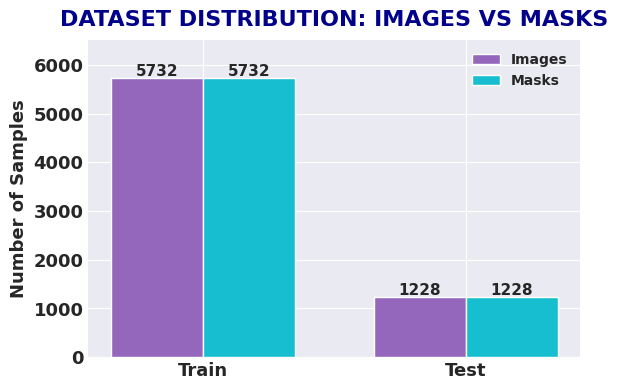

In [15]:
sns.set_style("darkgrid")
train_img = len(train_images)
train_msk = len(train_masks)
test_img  = len(test_images)
test_msk  = len(test_masks)
labels = ['Train', 'Test']
images = [train_img, test_img]
masks  = [train_msk, test_msk]
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(6, 4))
colors_images = ['#9467bd', '#9467bd']
colors_masks  = ['#17becf', '#17becf']
bars_images = plt.bar(x - width/2, images, width, label='Images', color=colors_images)
bars_masks  = plt.bar(x + width/2, masks, width, label='Masks', color=colors_masks)

for bar in bars_images:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, str(height), ha='center', fontweight='bold', fontsize=11)
for bar in bars_masks:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, str(height), ha='center', fontweight='bold', fontsize=11)

plt.xticks(x, labels, fontweight='heavy', fontsize=13)
plt.yticks(fontweight='heavy', fontsize=13)
plt.ylim(0,6500)
plt.ylabel("Number of Samples", fontweight='heavy', fontsize=13)
plt.title("DATASET DISTRIBUTION: IMAGES VS MASKS", fontweight='heavy', fontsize=16, y=1.02,color = 'darkblue')
plt.legend(prop={'weight':'bold'}, fontsize=12)
plt.tight_layout()
plt.show()

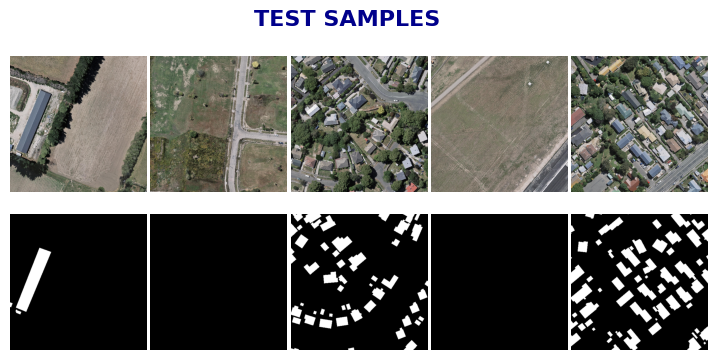

In [ ]:
num_samples = 5
random_indices = random.sample(range(len(test_images)), num_samples)

fig = plt.figure(figsize=(9, 4), facecolor='white')
fig.suptitle(
    "TEST SAMPLES",
    fontsize=16,
    fontweight='heavy',color='darkblue',
    y=0.98)

gs = gridspec.GridSpec(
    2, num_samples,
    figure=fig,
    hspace=0.05,
    wspace=0.03 )

for i, idx in enumerate(random_indices):
    img = Image.open(test_images[idx])
    mask = Image.open(test_masks[idx])

    ax1 = fig.add_subplot(gs[0, i])
    ax1.imshow(img)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, i])
    ax2.imshow(mask, cmap='gray')
    ax2.axis('off')

plt.show()


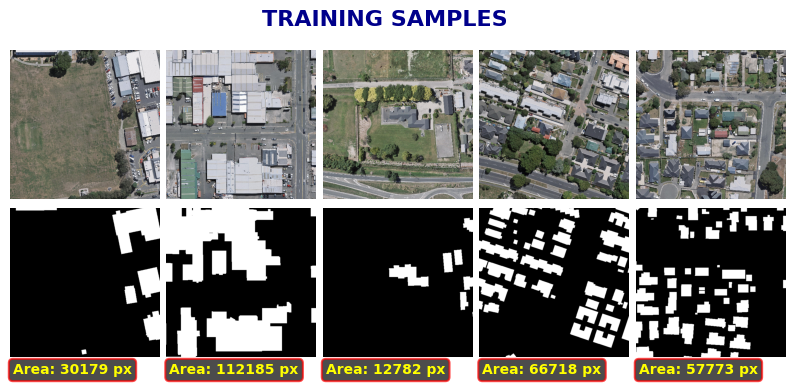

In [ ]:
num_samples = 5
random_indices = random.sample(range(len(train_images)), num_samples)

fig = plt.figure(figsize=(10, 4), facecolor='white')
fig.suptitle(
    "TRAINING SAMPLES",color = 'darkblue',
    fontsize=16,
    fontweight='heavy',
    y=0.98)

gs = gridspec.GridSpec(
    2, num_samples,
    figure=fig,
    hspace=0.05,
    wspace=0.05)

for i, idx in enumerate(random_indices):
    img = Image.open(train_images[idx])
    mask = Image.open(train_masks[idx]).convert('L')

    mask_np = np.array(mask)

    mask_pixel_count = np.sum(mask_np > 0)

    ax1 = fig.add_subplot(gs[0, i])
    ax1.imshow(img)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, i])
    ax2.imshow(mask_np, cmap='gray')
    ax2.axis('off')

    ax2.text(
        0.02, -0.04,
        f"Area: {mask_pixel_count} px",
        transform=ax2.transAxes,
        fontsize=10,
        fontweight='bold',
        color='yellow',
        verticalalignment='top',
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor='black',
            edgecolor='red',
            linewidth=1.5,
            alpha=0.7))

plt.show()


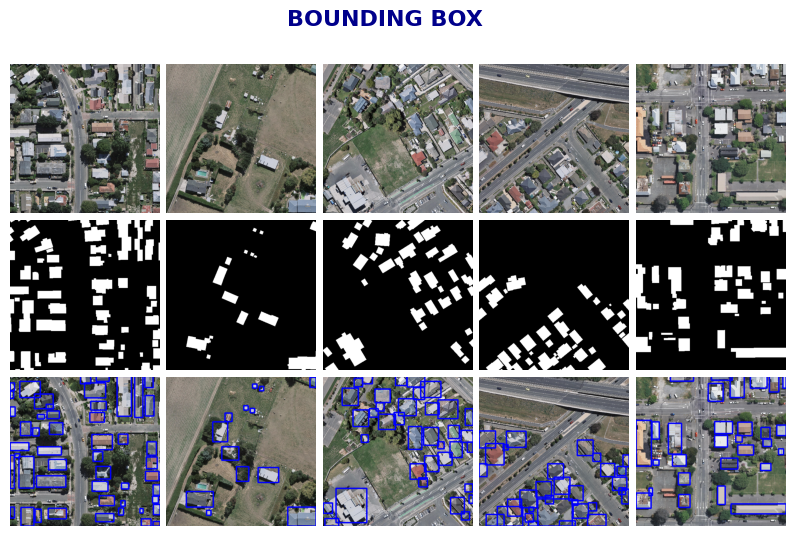

In [31]:
TRAIN_PATH = "/content/drive/MyDrive/DATASET/train"

train_images = sorted(glob(os.path.join(TRAIN_PATH, "Image", "*.png")))
train_masks  = sorted(glob(os.path.join(TRAIN_PATH, "Mask", "*.png")))

def draw_bounding_box(image, mask, color=(0, 0, 255), thickness=3):
    mask_bin = (mask > 127).astype(np.uint8) * 255
    contours, _ = cv2.findContours(
        mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    bbox_image = image.copy()

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 10:
            cv2.rectangle(
                bbox_image,
                (x, y),
                (x + w, y + h),
                color,
                thickness
            )
    return bbox_image

def visualize_samples(images, masks, num_samples=5):

    num_samples = min(num_samples, len(images))
    random_indices = random.sample(range(len(images)), num_samples)

    fig = plt.figure(figsize=(10, 6), facecolor='white')
    fig.suptitle(
    "BOUNDING BOX",color = 'darkblue',
    fontsize=16,
    fontweight='heavy',
    y=0.97)

    gs = gridspec.GridSpec(
        3, num_samples,
        figure=fig,
        hspace=0.05,
        wspace=0.05
    )

    for i, idx in enumerate(random_indices):

        img = cv2.imread(images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(masks[idx], cv2.IMREAD_GRAYSCALE)

        bbox_img = draw_bounding_box(img, mask)

        ax1 = fig.add_subplot(gs[0, i])
        ax1.imshow(img)
        ax1.axis('off')

        ax2 = fig.add_subplot(gs[1, i])
        ax2.imshow(mask, cmap='gray')
        ax2.axis('off')

        ax3 = fig.add_subplot(gs[2, i])
        ax3.imshow(bbox_img)
        ax3.axis('off')

    plt.show()

visualize_samples(train_images, train_masks, num_samples=5)


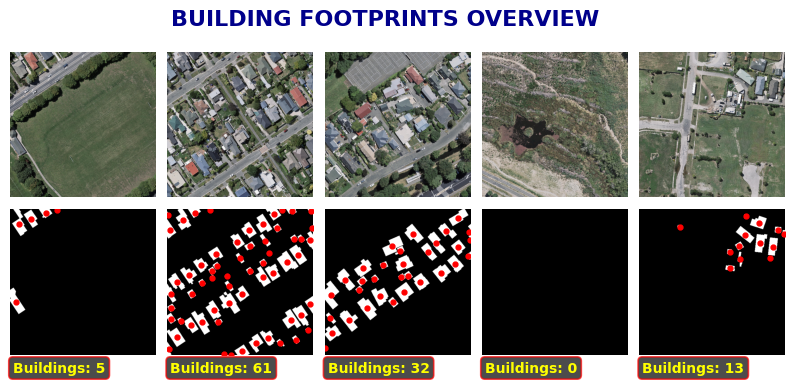

In [ ]:
num_images = 5
random_indices = random.sample(range(len(train_images)), num_images)


fig = plt.figure(figsize=(10, 4), facecolor='white')
fig.suptitle(
    "BUILDING FOOTPRINTS OVERVIEW",
    fontsize=16,
    fontweight='bold',
    color='darkblue',
    y=0.98)

gs = gridspec.GridSpec(
    2, num_images,
    figure=fig,
    hspace=0.05,
    wspace=0.08)

for i, idx in enumerate(random_indices):

    img = Image.open(train_images[idx])
    mask = Image.open(train_masks[idx]).convert('L')
    mask_np = np.array(mask)

    binary_mask = mask_np > 0
    labeled_mask, num_features = label(binary_mask)

    ax1 = fig.add_subplot(gs[0, i])
    ax1.imshow(img)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, i])
    ax2.imshow(mask_np, cmap='gray')
    ax2.axis('off')

    for obj_id in range(1, num_features + 1):
        ys, xs = np.where(labeled_mask == obj_id)
        if len(xs) > 0:
            cx = int(xs.mean())
            cy = int(ys.mean())
            ax2.plot(cx, cy, 'ro', markersize=3.5)

    ax2.text(
        0.02, -0.04,
        f"Buildings: {num_features}",
        transform=ax2.transAxes,
        fontsize=10,
        fontweight='bold',
        color='yellow',
        verticalalignment='top',
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor='black',
            edgecolor='red',
            linewidth=1.2,
            alpha=0.7))

plt.show()


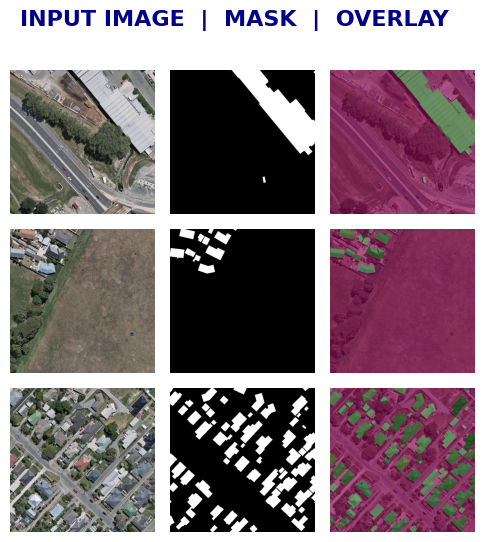

In [ ]:
indices = random.sample(range(len(train_images)), 3)
fig, axes = plt.subplots(3, 3, figsize=(6, 6), facecolor='white')

fig.suptitle(
    "INPUT IMAGE  |  MASK  |  OVERLAY",color ='darkblue',
    fontsize=16,
    fontweight='bold',
    y=0.98)

for row, idx in enumerate(indices):
    img = Image.open(train_images[idx])
    mask = Image.open(train_masks[idx]).convert('L')

    img_np = np.array(img)
    mask_np = np.array(mask)

    axes[row, 0].imshow(img_np)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_np, cmap='gray')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(img_np)
    axes[row, 2].imshow(mask_np, cmap='PiYG', alpha=0.6)
    axes[row, 2].axis('off')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


In [ ]:
class SegmentationGenerator(Sequence):
    def __init__(self, img_dir, mask_dir, batch_size=8, img_size=(128,128)):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_imgs = self.images[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_masks = self.masks[idx*self.batch_size:(idx+1)*self.batch_size]

        X = np.zeros((len(batch_imgs), *self.img_size, 3), dtype=np.float32)
        Y = np.zeros((len(batch_imgs), *self.img_size, 1), dtype=np.float32)

        for i, (img, mask) in enumerate(zip(batch_imgs, batch_masks)):
            im = cv2.imread(os.path.join(self.img_dir, img))
            im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            im = cv2.resize(im, self.img_size) / 255.0

            mk = cv2.imread(os.path.join(self.mask_dir, mask), 0)
            mk = cv2.resize(mk, self.img_size) / 255.0
            mk = (mk > 0.5).astype(np.float32)
            mk = np.expand_dims(mk, -1)

            X[i], Y[i] = im, mk

        return X, Y


In [ ]:
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2*inter + smooth)/(tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_coef_threshold(y_true, y_pred, threshold=0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    smooth = 1e-6
    return (2*inter + smooth)/(tf.reduce_sum(y_true_f)+tf.reduce_sum(y_pred_f)+smooth)

def iou_coef_threshold(y_true, y_pred, threshold=0.5):
    y_pred_bin = tf.cast(y_pred > threshold, tf.float32)
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred_bin, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    smooth = 1e-6
    return (inter + smooth)/(union + smooth)


In [ ]:
def CBAMBlock(x, reduction=16):
    ch = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)

    dense1 = layers.Dense(ch // reduction, activation='relu')
    dense2 = layers.Dense(ch)

    avg_out = dense2(dense1(avg_pool))
    max_out = dense2(dense1(max_pool))

    channel_att = layers.Activation('sigmoid')(avg_out + max_out)
    channel_att = layers.Reshape((1,1,ch))(channel_att)
    x = layers.Multiply()([x, channel_att])

    avg_sp = layers.Lambda(lambda t: tf.reduce_mean(t, axis=-1, keepdims=True))(x)
    max_sp = layers.Lambda(lambda t: tf.reduce_max(t, axis=-1, keepdims=True))(x)

    concat = layers.Concatenate()([avg_sp, max_sp])
    spatial_att = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(concat)

    return layers.Multiply()([x, spatial_att])

def ResidualBlock(x, f):
    s = x
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if s.shape[-1] != f:
        s = layers.Conv2D(f, 1)(s)
    return layers.ReLU()(layers.Add()([x, s]))

def ViTBlock(x, heads=4):
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x_flat = layers.Reshape((h*w, c))(x)
    attn = layers.MultiHeadAttention(num_heads=heads, key_dim=c)(x_flat, x_flat)
    x_flat = layers.LayerNormalization()(x_flat + attn)
    mlp = layers.Dense(c*4, activation='relu')(x_flat)
    mlp = layers.Dense(c)(mlp)
    x_flat = layers.LayerNormalization()(x_flat + mlp)
    return layers.Reshape((h, w, c))(x_flat)

def CBAMResViTUNetPlus(input_shape=(128,128,3), features=[64,128,256], heads=4):
    inp = layers.Input(shape=input_shape)
    e1 = CBAMBlock(ResidualBlock(inp, features[0]))
    e2 = CBAMBlock(ResidualBlock(layers.MaxPooling2D()(e1), features[1]))
    e3 = CBAMBlock(ResidualBlock(layers.MaxPooling2D()(e2), features[2]))
    v = ViTBlock(e3, heads)
    d2 = layers.Conv2DTranspose(features[1], 2, strides=2)(v)
    d2 = ResidualBlock(layers.Concatenate()([d2, e2]), features[1])
    d1 = layers.Conv2DTranspose(features[0], 2, strides=2)(d2)
    d1 = ResidualBlock(layers.Concatenate()([d1, e1]), features[0])
    out = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return Model(inp, out)

def ROA_optimize(train_gen, val_gen, n_pop=1, t_max=5, threshold=0.5):
    lr_space = [1e-4, 5e-4]
    feat_space = [[32,64,128],[64,128,256]]
    head_space = [2,4]
    best, best_score = None, -1

    for t in range(t_max):
        print(f"\nROA Iteration {t+1}")
        for _ in range(n_pop):
            params = {
                "lr": random.choice(lr_space),
                "features": random.choice(feat_space),
                "heads": random.choice(head_space)
            }

            model = CBAMResViTUNetPlus(features=params["features"], heads=params["heads"])
            model.compile(optimizer=optimizers.Adam(params["lr"]), loss=dice_loss)

            model.fit(train_gen, epochs=1, verbose=0)

            y_true_all, y_pred_all = [], []

            for i in range(len(val_gen)):
                X_val, Y_val = val_gen[i]
                preds = model.predict(X_val, verbose=0)
                preds_bin = (preds > threshold).astype(np.uint8)

                y_true_all.append(np.array(Y_val>0.5, dtype=np.uint8).flatten())
                y_pred_all.append(preds_bin.flatten())

            y_true_all = np.concatenate(y_true_all)
            y_pred_all = np.concatenate(y_pred_all)

            inter = np.sum(y_true_all*y_pred_all)
            dice_score = (2*inter + 1e-6)/(np.sum(y_true_all)+np.sum(y_pred_all)+1e-6)

            print(params, "Dice:", round(dice_score,4))

            if dice_score > best_score:
                best_score, best = dice_score, params.copy()

    print("\nBest Parameters:", best)
    return best



In [ ]:
def train_final_model(train_gen, val_gen, params, epochs=10):
    model = CBAMResViTUNetPlus(features=params["features"], heads=params["heads"])
    model.compile(
        optimizer=optimizers.Adam(params["lr"]),
        loss=dice_loss,
        metrics=[dice_coef_threshold, iou_coef_threshold]
    )
    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, verbose=1)
    return model, history

def evaluate_segmentation(model, generator, threshold=0.5):
    y_true_all, y_pred_all = [], []
    for i in range(len(generator)):
        X, Y = generator[i]
        preds = model.predict(X, verbose=0)
        preds_bin = (preds > threshold).astype(np.uint8)
        y_true_all.append((Y>0.5).astype(np.uint8).flatten())
        y_pred_all.append(preds_bin.flatten())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    smooth = 1e-6
    inter = np.sum(y_true_all*y_pred_all)
    dice = (2*inter+smooth)/(np.sum(y_true_all)+np.sum(y_pred_all)+smooth)
    union = np.sum(y_true_all)+np.sum(y_pred_all)-inter
    iou = (inter+smooth)/(union+smooth)
    acc = accuracy_score(y_true_all, y_pred_all)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec = recall_score(y_true_all, y_pred_all, zero_division=0)

    print("\n--- SEGMENTATION METRICS : RHIZOSTOMA CBAM-ResViT-UNet+ ---")
    print(f"Dice      : {dice:.4f}")
    print(f"IoU       : {iou:.4f}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print("---------------------------")
    return dice, iou, acc, prec, rec


In [ ]:
train_gen = SegmentationGenerator(
    "/content/drive/MyDrive/DATASET/train/Image",
    "/content/drive/MyDrive/DATASET/train/Mask",
    batch_size=8
)
val_gen = SegmentationGenerator(
    "/content/drive/MyDrive/DATASET/test/Image",
    "/content/drive/MyDrive/DATASET/test/Mask",
    batch_size=8
)

best_params = ROA_optimize(train_gen, val_gen, n_pop=1, t_max=5)

final_model, history = train_final_model(train_gen, val_gen, best_params, epochs=10)

metrics = evaluate_segmentation(final_model, val_gen)



ROA Iteration 1
{'lr': 0.0005, 'features': [32, 64, 128], 'heads': 2} Dice: 0.8116

ROA Iteration 2
{'lr': 0.0001, 'features': [32, 64, 128], 'heads': 4} Dice: 0.8003

ROA Iteration 3
{'lr': 0.0005, 'features': [32, 64, 128], 'heads': 4} Dice: 0.8149

ROA Iteration 4
{'lr': 0.0005, 'features': [64, 128, 256], 'heads': 2} Dice: 0.6631

ROA Iteration 5
{'lr': 0.0005, 'features': [32, 64, 128], 'heads': 2} Dice: 0.7823

Best Parameters: {'lr': 0.0005, 'features': [32, 64, 128], 'heads': 4}
Epoch 1/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 207s 253ms/step - dice_coef_threshold: 0.6692 - iou_coef_threshold: 0.5201 - loss: 0.3422 - val_dice_coef_threshold: 0.7432 - val_iou_coef_threshold: 0.5994 - val_loss: 0.2582
Epoch 2/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 164s 229ms/step - dice_coef_threshold: 0.8087 - iou_coef_threshold: 0.6859 - loss: 0.1934 - val_dice_coef_threshold: 0.7592 - val_iou_coef_threshold: 0.6158 - val_loss: 0.2412
Epoch 3/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 164s 228ms/step - dice_coef_thresho


--- SEGMENTATION METRICS : RHIZOSTOMA CBAM-ResViT-UNet+ ---
Dice      : 0.8712
IoU       : 0.7717
Accuracy  : 0.9609
Precision : 0.9136
Recall    : 0.8325
---------------------------


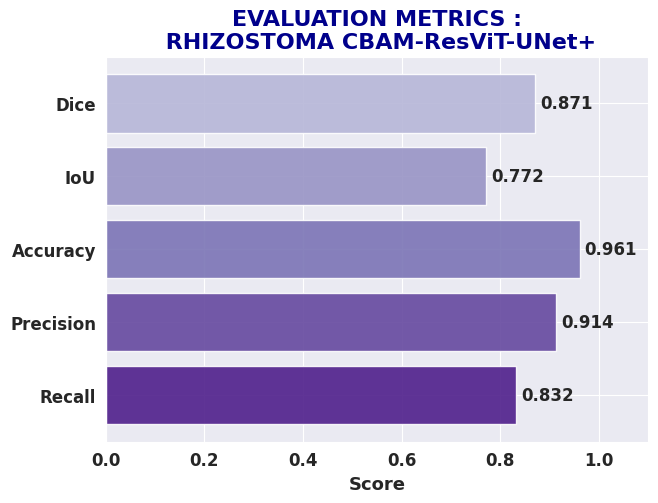

In [ ]:
def plot_segmentation_metrics_horizontal(metrics, model_name="RHIZOSTOMA CBAM-ResViT-UNet+"):

    dice, iou, acc, prec, rec = metrics
    metric_names = ['Dice', 'IoU', 'Accuracy', 'Precision', 'Recall']
    values = [dice, iou, acc, prec, rec]

    cmaps = {
        "RHIZOSTOMA CBAM-ResViT-UNet+": plt.cm.Purples
    }
    cmap = cmaps.get(model_name, plt.cm.Purples)
    colors = cmap(np.linspace(0.4, 0.9, len(values)))

    sns.set_style("darkgrid")
    plt.figure(figsize=(7,5))
    bars = plt.barh(metric_names, values, color=colors, alpha=0.9)

    for bar, value in zip(bars, values):
        plt.text(
            value + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{value:.3f}",
            va="center",
            fontsize=12,
            weight="bold"
        )

    plt.xlim(0,1)
    plt.xlabel("Score", fontsize=13, fontweight='bold')
    plt.title(f"EVALUATION METRICS :\n {model_name}",
              fontsize=16, fontweight='bold', color='darkblue')
    plt.xlim(0, 1.1)
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.show()

metrics = evaluate_segmentation(final_model, val_gen)
plot_segmentation_metrics_horizontal(metrics, model_name="RHIZOSTOMA CBAM-ResViT-UNet+")


/tmp/ipython-input-739769398.py:13: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.

/tmp/ipython-input-739769398.py:15: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "r-o" (-> color='r'). The keyword argument will take precedence.



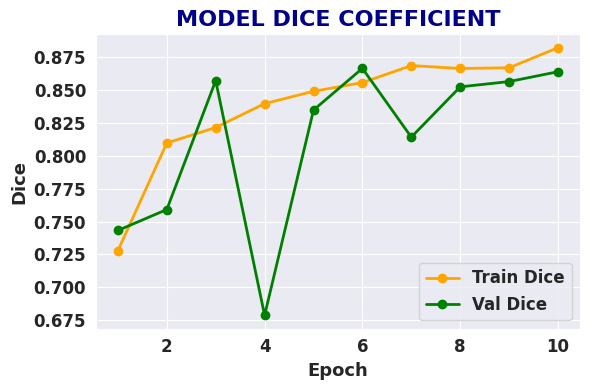

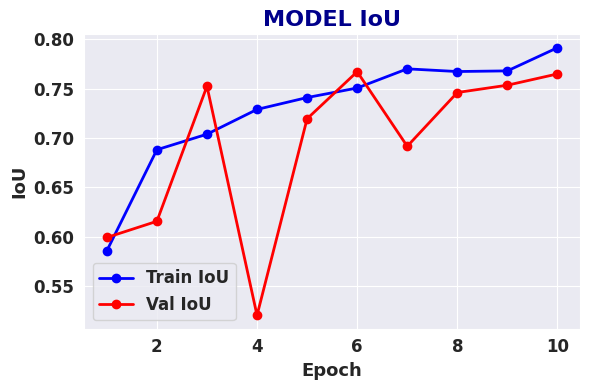

In [ ]:
def plot_dice_iou_separate(history):
    sns.set_style("darkgrid")
    loss = history.history['loss']
    epochs = range(1, len(loss)+1)

    dice = history.history.get('dice_coef_threshold', [])
    val_dice = history.history.get('val_dice_coef_threshold', [])
    iou = history.history.get('iou_coef_threshold', [])
    val_iou = history.history.get('val_iou_coef_threshold', [])

    plt.figure(figsize=(6,4))
    if dice:
        plt.plot(epochs, dice, 'b-o', color = 'orange', label='Train Dice', linewidth=2)
    if val_dice:
        plt.plot(epochs, val_dice, 'r-o', color = 'green' , label='Val Dice', linewidth=2)
    plt.title("MODEL DICE COEFFICIENT", fontsize=16, fontweight='bold', color = 'darkblue')
    plt.xlabel("Epoch", fontsize=13, fontweight='bold')
    plt.ylabel("Dice", fontsize=13, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(prop={'size':12, 'weight':'bold'})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    if iou:
        plt.plot(epochs, iou, 'b-o', label='Train IoU', linewidth=2)
    if val_iou:
        plt.plot(epochs, val_iou, 'r-o', label='Val IoU', linewidth=2)
    plt.title("MODEL IoU", fontsize=16, fontweight='bold',color = 'darkblue')
    plt.xlabel("Epoch", fontsize=13, fontweight='bold')
    plt.ylabel("IoU", fontsize=13, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.legend(prop={'size':12, 'weight':'bold'})
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_dice_iou_separate(history)


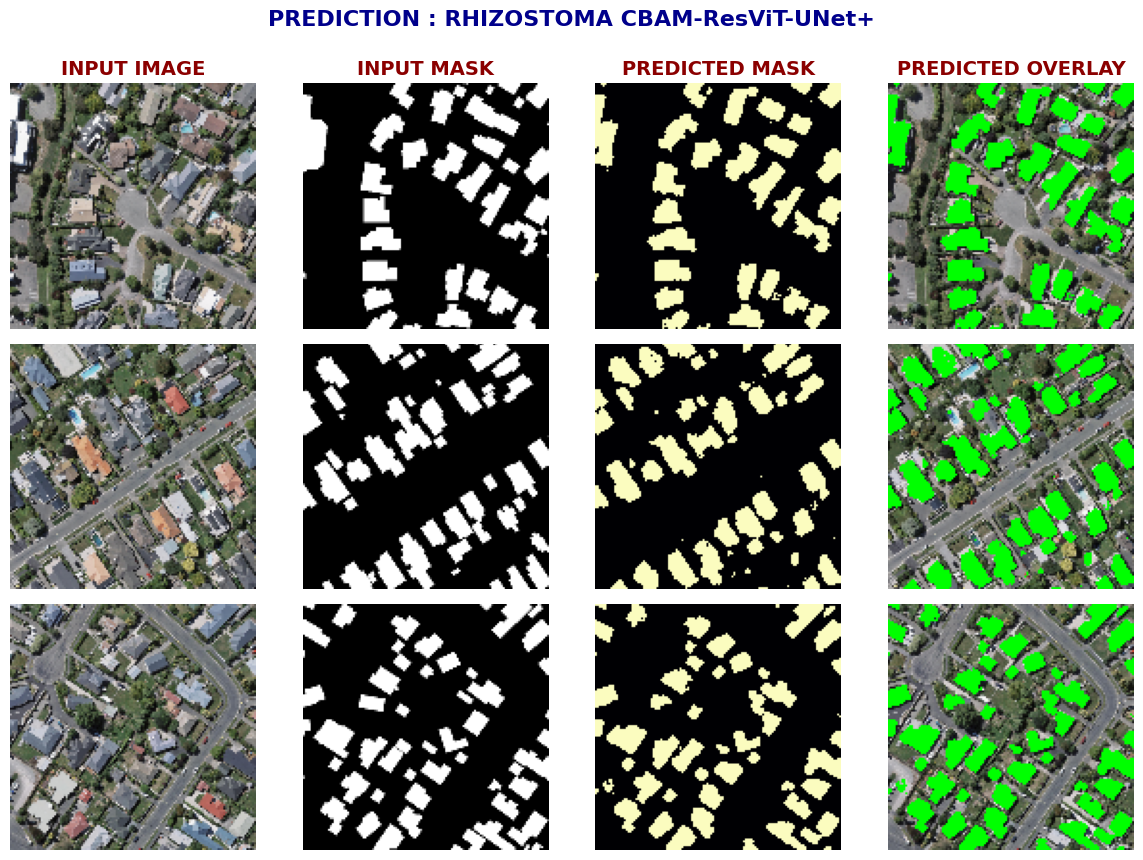

In [ ]:
def predict_and_show_overlay(model, img_paths, mask_paths, img_size=(128,128), threshold=0.5):
    n = len(img_paths)
    fig, axes = plt.subplots(n, 4, figsize=(12, 3*n))

    if n == 1:
        axes = np.expand_dims(axes, 0)

    fig.suptitle("PREDICTION : RHIZOSTOMA CBAM-ResViT-UNet+",
                 fontsize=16, fontweight='bold', y=0.95, color='darkblue')

    column_titles = ["INPUT IMAGE", "INPUT MASK", "PREDICTED MASK", "PREDICTED OVERLAY"]
    for ax, col_title in zip(axes[0], column_titles):
        ax.set_title(col_title, fontsize=14, fontweight='bold', color='darkred')

    for i, (img_path, mask_path) in enumerate(zip(img_paths, mask_paths)):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, img_size) / 255.0
        input_tensor = np.expand_dims(img_resized, 0)

        mask = cv2.imread(mask_path, 0)
        mask_resized = cv2.resize(mask, img_size) / 255.0

        pred = model.predict(input_tensor, verbose=0)[0,:,:,0]
        pred_bin = (pred > threshold).astype(np.float32)

        overlay = img_resized.copy()
        overlay[pred_bin==1] = [0, 1, 0]

        axes[i,0].imshow(img_resized)
        axes[i,1].imshow(mask_resized, cmap='gray')
        axes[i,2].imshow(pred_bin, cmap='magma')
        axes[i,3].imshow(overlay)

        for j in range(4):
            axes[i,j].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.15)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

img_list = [
    "/content/drive/MyDrive/DATASET/test/Image/test_0024.png",
    "/content/drive/MyDrive/DATASET/test/Image/test_0110.png",
    "/content/drive/MyDrive/DATASET/test/Image/test_0030.png"
]

mask_list = [
    "/content/drive/MyDrive/DATASET/test/Mask/test_0024.png",
    "/content/drive/MyDrive/DATASET/test/Mask/test_0110.png",
    "/content/drive/MyDrive/DATASET/test/Mask/test_0030.png"
]


predict_and_show_overlay(final_model, img_list, mask_list, img_size=(128,128))

/tmp/ipython-input-2437012534.py:79: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



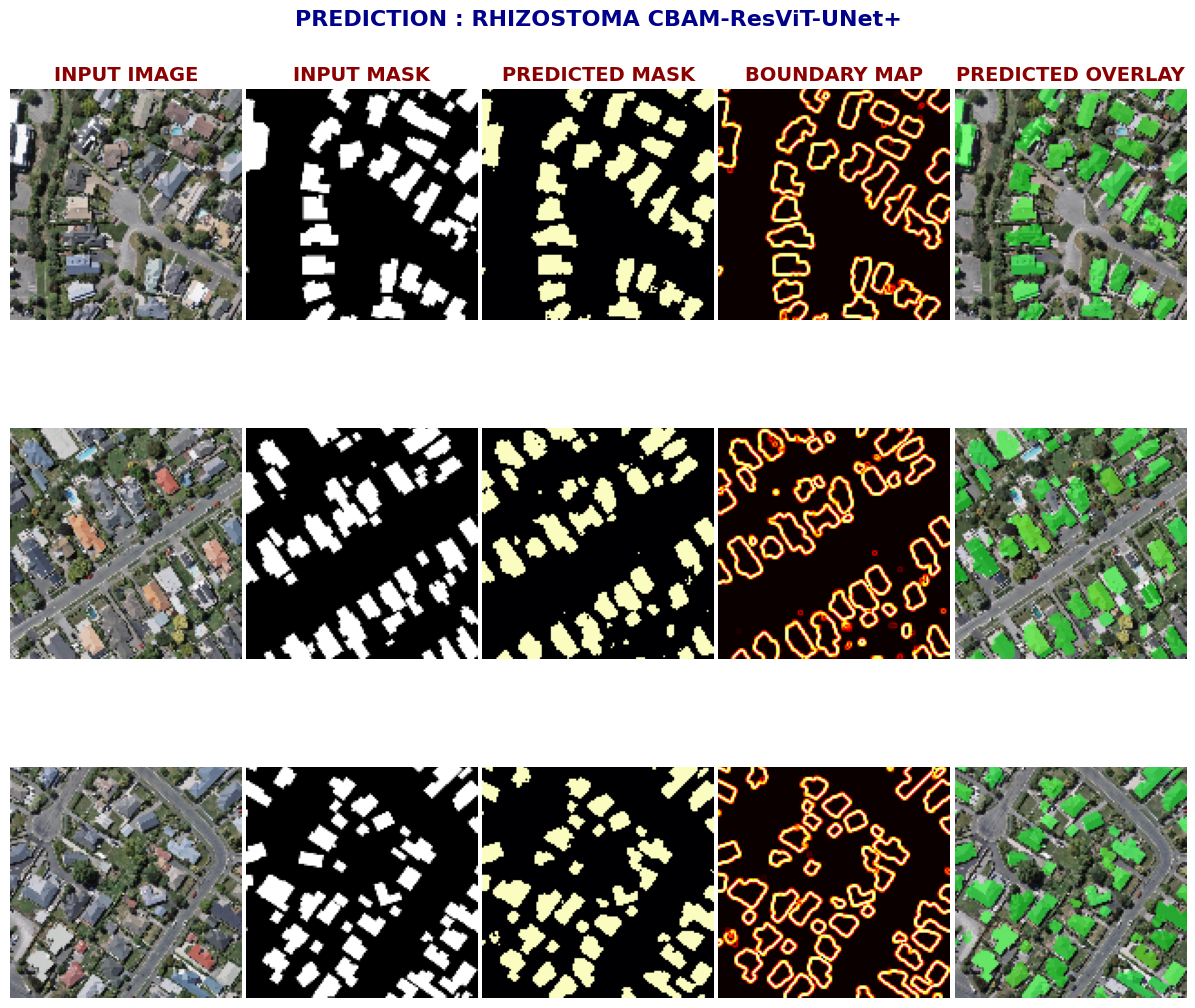

In [ ]:
def predict_boundary_overlay_gridspec(
    model,
    img_paths,
    mask_paths,
    img_size=(128,128),
    threshold=0.5,
    alpha=0.5
):
    n = len(img_paths)

    fig = plt.figure(figsize=(12, 3*n), facecolor="white")

    fig.suptitle(
        "PREDICTION : RHIZOSTOMA CBAM-ResViT-UNet+",
        fontsize=16,
        fontweight="bold",
        color="darkblue",
        y=0.98
    )

    gs = gridspec.GridSpec(
        n, 5,
        figure=fig,
        hspace=0.12,
        wspace=0.08
    )

    column_titles = [
        "INPUT IMAGE",
        "TRUE MASK",
        "PREDICTED MASK",
        "BOUNDARY MAP",
        "COMPOSITE IMAGE"
    ]

    for i, (img_path, mask_path) in enumerate(zip(img_paths, mask_paths)):

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size).astype(np.float32) / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, img_size).astype(np.float32) / 255.0

        pred = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )[0, :, :, 0]

        pred_bin = (pred > threshold).astype(np.uint8)

        edges = filters.sobel(pred)

        overlay = img.copy()
        overlay[pred_bin == 1] = (
            (1 - alpha) * overlay[pred_bin == 1]
            + alpha * np.array([0, 1, 0])
        )

        visuals = [
            (img, None),
            (mask, "gray"),
            (pred_bin, "magma"),
            (edges, "hot"),
            (overlay, None)
        ]

        for j, (data, cmap) in enumerate(visuals):
            ax = fig.add_subplot(gs[i, j])
            ax.imshow(data, cmap=cmap)
            ax.axis("off")

            if i == 0:
                ax.set_title(
                    column_titles[j],
                    fontsize=12,
                    fontweight="bold",
                    color="darkred"
                )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

img_list = [
    "/content/drive/MyDrive/DATASET/test/Image/test_0024.png",
    "/content/drive/MyDrive/DATASET/test/Image/test_0110.png",
    "/content/drive/MyDrive/DATASET/test/Image/test_0030.png"
]

mask_list = [
    "/content/drive/MyDrive/DATASET/test/Mask/test_0024.png",
    "/content/drive/MyDrive/DATASET/test/Mask/test_0110.png",
    "/content/drive/MyDrive/DATASET/test/Mask/test_0030.png"
]


predict_boundary_overlay(
    model=final_model,
    img_paths=img_list,
    mask_paths=mask_list,
    img_size=(128,128),
    threshold=0.5,
    alpha=0.5
)